<Axes: xlabel='cylinders', ylabel='model_year'>

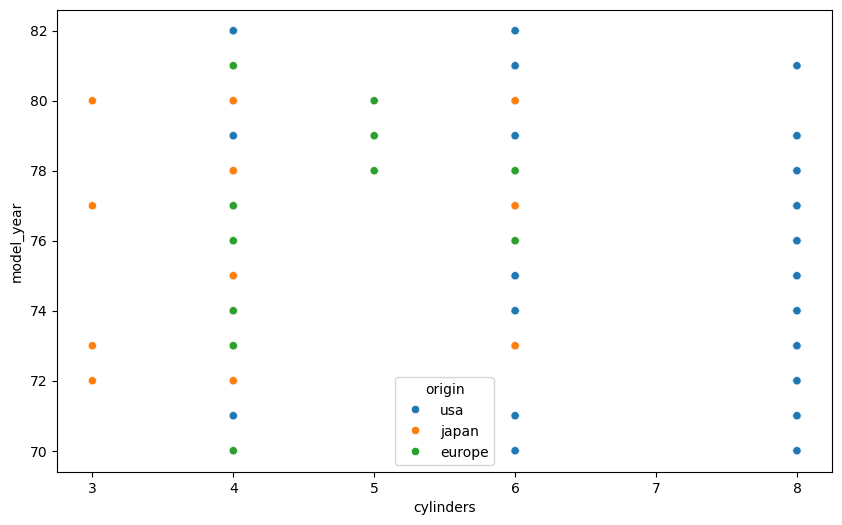

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

data = sns.load_dataset('mpg')
fig, ax = plt.subplots(figsize=(10,6))
# ax.scatter(data['cylinders'],data['model_year'])

sns.scatterplot(data=data, x='cylinders', y='model_year', hue='origin')


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
# Titanic 데이터 로드
titanic = sns.load_dataset('titanic')

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


class
Third     55.106622
First     24.242424
Second    20.650954
Name: count, dtype: float64


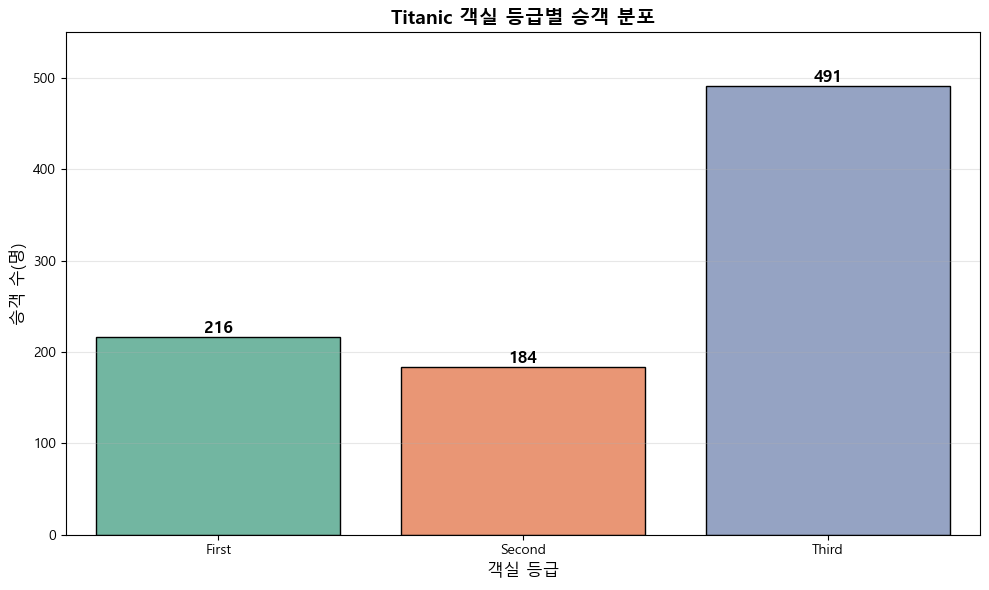

In [20]:
# countplot

fig, ax = plt.subplots(figsize=(10, 6))

print(titanic['class'].value_counts()/len(titanic) * 100)

sns. countplot(data=titanic, x='class', ax=ax, palette='Set2', edgecolor='black', hue='class')

# 막대 위 수치 표시
for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight = 'bold')

ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('승객 수(명)', fontsize=12)
ax.set_title('Titanic 객실 등급별 승객 분포', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 550)
plt.tight_layout()
plt.show()


C:\Users\Playdata\AppData\Local\Temp\ipykernel_27944\2321762395.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y*100)}%' for y in ax.get_yticks()])


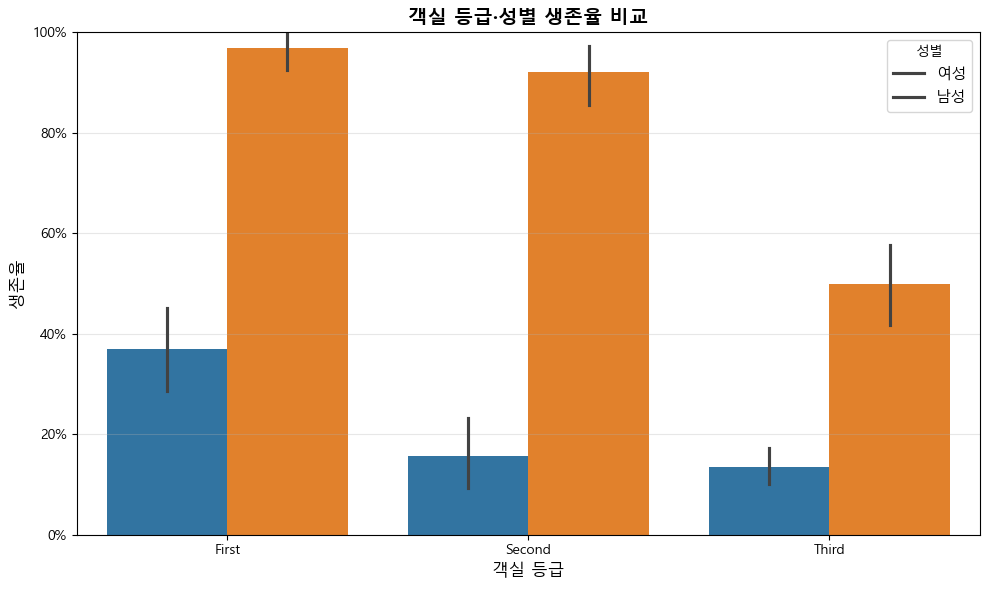

class   sex   
First   female    0.968085
        male      0.368852
Second  female    0.921053
        male      0.157407
Third   female    0.500000
        male      0.135447
Name: survived, dtype: float64


C:\Users\Playdata\AppData\Local\Temp\ipykernel_27944\2321762395.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_class_sex = titanic.groupby(['class', 'sex'])['survived'].mean()


In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

# Barplot with hue
sns.barplot(data=titanic, x='class', y='survived', hue='sex')

ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('생존율', fontsize=12)
ax.set_title('객실 등급·성별 생존율 비교', fontsize=14, fontweight='bold')
ax.legend(title='성별', labels=['여성', '남성'], fontsize=11)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

# # Y축을 백분율로 표시
ax.set_yticklabels([f'{int(y*100)}%' for y in ax.get_yticks()])

plt.tight_layout()
plt.show()

# # 통계 확인
survival_by_class_sex = titanic.groupby(['class', 'sex'])['survived'].mean()
print(survival_by_class_sex)

#  인사이트: 1등급 여성 생존율 96.8% vs 3등급 남성 13.5% → 23배 차이
#  '여성과 어린이 먼저' 원칙이 1등급에서 더 철저히 적용됨

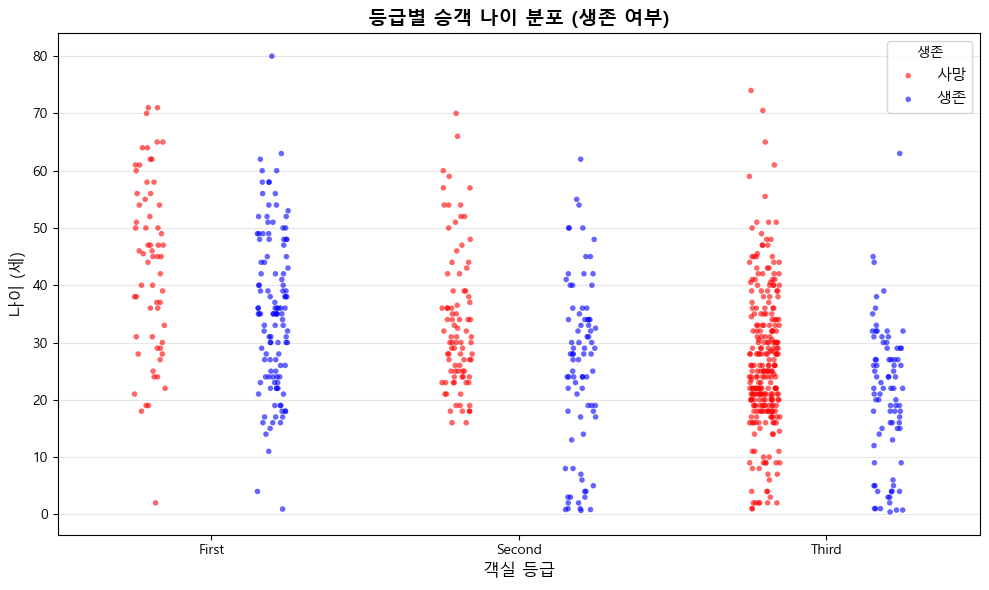

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

# Stripplot 생성
sns.stripplot(data=titanic, x='class', y='age', hue='survived', ax=ax,
              palette={0:'r', 1:'b'}, alpha=0.6, size=4, dodge=True)



ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('나이 (세)', fontsize=12)
ax.set_title('등급별 승객 나이 분포 (생존 여부)', fontsize=14, fontweight='bold')
ax.legend(title='생존', labels=['사망', '생존'], fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#  인사이트: 1등급 어린이(0-10세)는 거의 생존, 3등급은 나이 무관하게 사망률 높음
#  데이터 오버랩으로 밀도 파악 어려움 → Swarmplot 활용 필요

c:\Users\Playdata\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 17.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Playdata\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 62.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Playdata\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 32.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Playdata\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 15.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Playdata\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning:

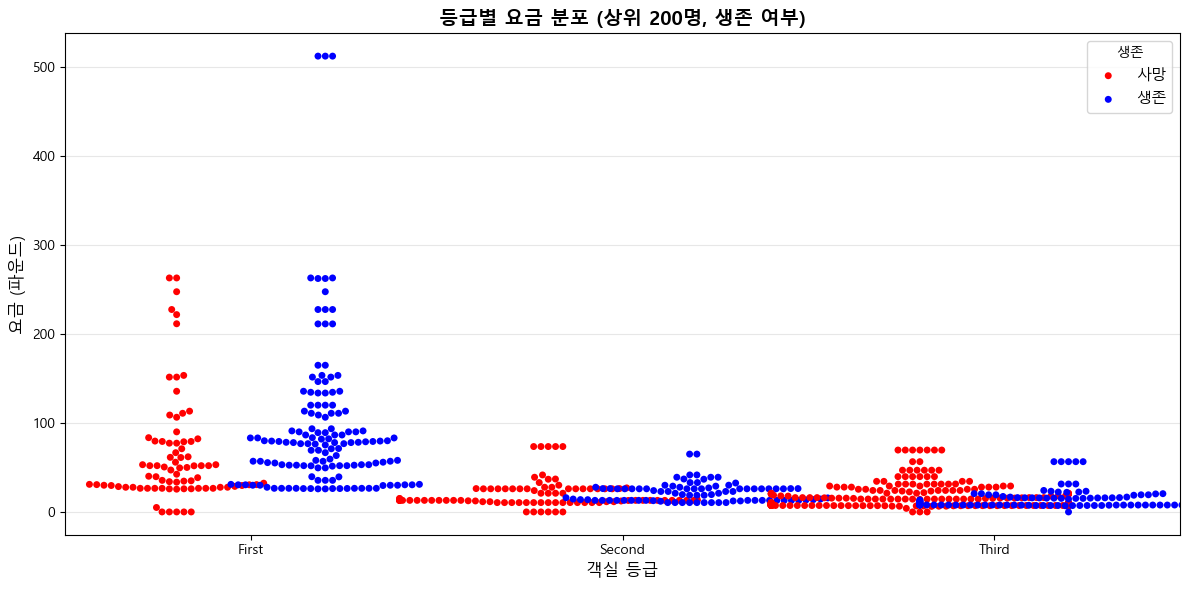

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))

# 요금 상위 200명만 (가독성 위해)
titanic_fare = titanic.nlargest(200, 'fare')

# Swarmplot 생성
sns.swarmplot(data=titanic, x='class', y = 'fare', hue='survived', ax=ax, dodge=True,
              palette={0:'r', 1:'b'}, edgecolor='k', size=5)

ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('요금 (파운드)', fontsize=12)
ax.set_title('등급별 요금 분포 (상위 200명, 생존 여부)', fontsize=14, fontweight='bold')
ax.legend(title='생존', labels=['사망', '생존'], fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#  인사이트: 1등급 고액 요금 승객 대부분 생존 → 경제력이 구명보트 접근성과 연결
#  3등급은 요금 차이가 작지만 생존율 편차 큼 → 다른 요인(위치, 나이) 영향

In [39]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


C:\Users\Playdata\AppData\Local\Temp\ipykernel_27944\2444269547.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels([f'{int(y*100)}%' for y in axes[1].get_yticks()])


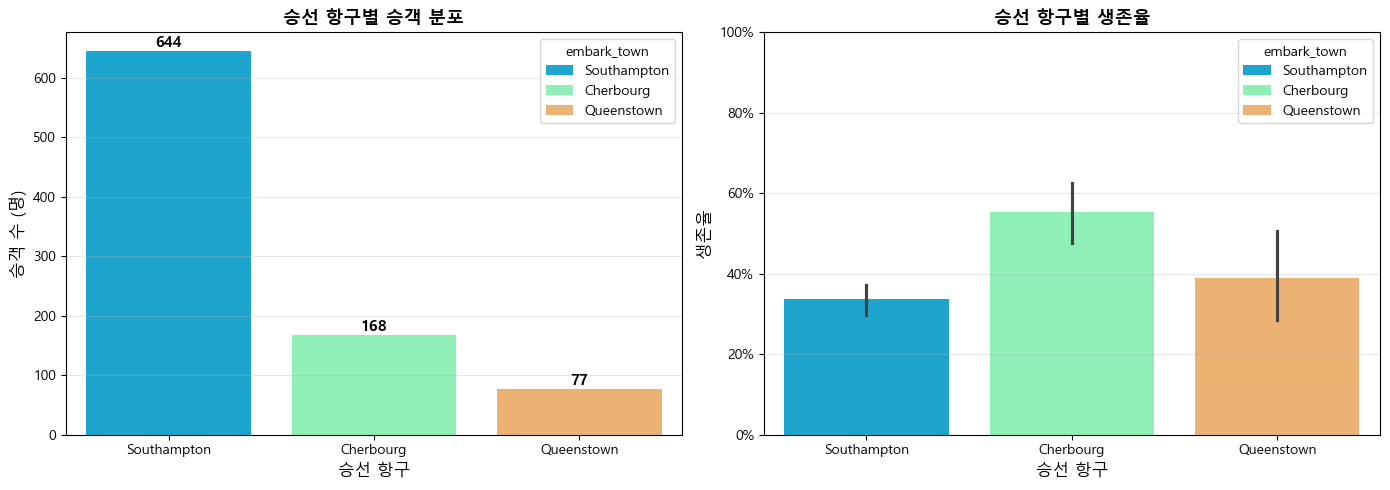

            survived           
                mean  sum count
embark_town                    
Cherbourg      0.554   93   168
Queenstown     0.390   30    77
Southampton    0.337  217   644


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌측: 항구별 승객 수
sns.countplot(data=titanic, x='embark_town', ax=axes[0], palette='rainbow', hue='embark_town')


for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=11, fontweight='bold')

axes[0].set_xlabel('승선 항구', fontsize=12)
axes[0].set_ylabel('승객 수 (명)', fontsize=12)
axes[0].set_title('승선 항구별 승객 분포', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# 우측: 항구별 생존율
sns.barplot(data=titanic, x='embark_town',y='survived', ax=axes[1], palette = 'rainbow', hue='embark_town')

axes[1].set_xlabel('승선 항구', fontsize=12)
axes[1].set_ylabel('생존율', fontsize=12)
axes[1].set_title('승선 항구별 생존율', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].set_yticklabels([f'{int(y*100)}%' for y in axes[1].get_yticks()])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 상세 분석
embark_stats = titanic.groupby('embark_town').agg({
    'survived': ['mean', 'sum', 'count']
}).round(3)
print(embark_stats)

#  인사이트: Cherbourg 승선객이 생존율 55% (Southampton 34% 대비 1.6배)
#  Cherbourg는 1등급 비율 높음 → 등급이 생존율 차이의 주요 변수

In [48]:
factors = {
    '성별(여성)': titanic[titanic['sex']=='female']['survived'].mean(),
    '성별(남성)': titanic[titanic['sex']=='male']['survived'].mean(),
    '1등급': titanic[titanic['class']=='First']['survived'].mean(),
    '3등급': titanic[titanic['class']=='Third']['survived'].mean(),
    '어린이(<10세)': titanic[titanic['age']<10]['survived'].mean(),
    '성인(30-50세)': titanic[(titanic['age']>=30) & (titanic['age']<50)]['survived'].mean(),
    '시니어(60세이상)': titanic[(titanic['age']>=60)]['survived'].mean()
}

factors_df = pd.DataFrame(list(factors.items()), columns=['요인', '생존율'])
factors_df.sort_values(by=['생존율'], ascending=False)

,요인,생존율
0,성별(여성),0.742038
2,1등급,0.629630
4,어린이(<10세),0.612903
5,성인(30-50세),0.417969
6,시니어(60세이상),0.269231
3,3등급,0.242363
1,성별(남성),0.188908


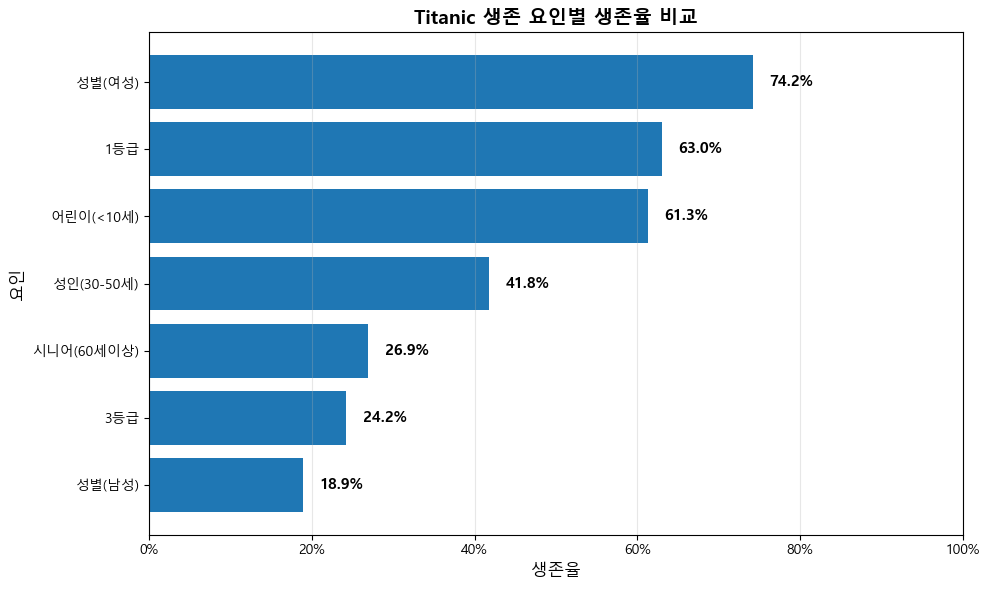

In [51]:
# 각 범주형 변수별 생존율 계산
factors = {
    '성별(여성)': titanic[titanic['sex']=='female']['survived'].mean(),
    '성별(남성)': titanic[titanic['sex']=='male']['survived'].mean(),
    '1등급': titanic[titanic['class']=='First']['survived'].mean(),
    '3등급': titanic[titanic['class']=='Third']['survived'].mean(),
    '어린이(<10세)': titanic[titanic['age']<10]['survived'].mean(),
    '성인(30-50세)': titanic[(titanic['age']>=30) & (titanic['age']<50)]['survived'].mean(),
    '시니어(60세이상)': titanic[(titanic['age']>=60)]['survived'].mean()
}

factors_df = pd.DataFrame(list(factors.items()), columns=['요인', '생존율'])
factors_df = factors_df.sort_values('생존율', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(factors_df['요인'], factors_df['생존율'])



# 수치 표시
for i, (factor, rate) in enumerate(zip(factors_df['요인'], factors_df['생존율'])):
    ax.text(rate + 0.02, i, f'{rate*100:.1f}%', 
            va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('생존율', fontsize=12)
ax.set_ylabel('요인', fontsize=12)
ax.set_title('Titanic 생존 요인별 생존율 비교', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

#  인사이트: 성별이 가장 강력한 요인 (여성 74% vs 남성 19%)
#  등급도 중요하지만 성별만큼 극명하지는 않음
#  어린이 우대 정책도 효과적 (59% 생존)